In [1]:
import glob
import os
import shlex
import shutil
import subprocess
import warnings

import cv2
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D 

try:
    import open3d as o3d
    HAVE_OPEN3D = True
except ImportError:
    o3d = None
    HAVE_OPEN3D = False

ROOT = r'C:\ITMO\designing_neural_network_architectures_2025_02\seminar_04\data'
VIDEO_PATH = os.path.join(ROOT, 'IMG_9815.mp4')
FRAMES_DIR = os.path.join(ROOT, 'frames')
FRAMES_FILTERED_DIR = os.path.join(ROOT, 'frames_filtered')
COLMAP_DIR = os.path.join(ROOT, 'colmap')
DENSE_DIR = os.path.join(ROOT, 'dense')

DB_PATH = os.path.join(COLMAP_DIR, 'database.db')
SPARSE_PATH = os.path.join(COLMAP_DIR, 'sparse')
SPARSE_MODEL_0 = os.path.join(SPARSE_PATH, '0')
DENSE_WORK = os.path.join(DENSE_DIR, 'workspace')

for _path in [os.path.join(ROOT, 'input'), FRAMES_DIR, FRAMES_FILTERED_DIR, COLMAP_DIR, DENSE_DIR]:
    os.makedirs(_path, exist_ok=True)

_COLMAP_DIR = r"C:\Users\Admin\Downloads\colmap-x64-windows-cuda"


def colmap_exe():
    return r"C:\Users\Admin\Downloads\colmap-x64-windows-cuda\bin\colmap.exe"

def ffmpeg_exe():
    return r"C:\Users\Admin\Downloads\ffmpeg-master-latest-win64-gpl\bin\ffmpeg.exe"


def _argv_unquote(parts):
    out = []
    for x in parts:
        if len(x) >= 2 and x[0] == x[-1] and x[0] in ('"', "'"):
            out.append(x[1:-1])
        else:
            out.append(x)
    return out


def run(cmd: str):
    print('>>', cmd)
    posix = os.name == 'posix'
    parts = _argv_unquote(shlex.split(cmd, posix=posix))
    if not parts:
        return
    if parts[0] == 'colmap':
        c = colmap_exe()
        if not c:
            raise FileNotFoundError(
                'Исполняемый файл COLMAP не найден. Укажите COLMAP_EXE, COLMAP_PROGRAM_DIR '
                'или добавьте COLMAP в PATH. https://colmap.github.io/download.html'
            )
        parts[0] = c
    if parts[0] == 'ffmpeg':
        ffmpeg = ffmpeg_exe()
        if not ffmpeg:
            raise FileNotFoundError("No ffmpeg")
        parts[0] = ffmpeg
    subprocess.run(parts, check=True)


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.



При заданном `max_points` функция `show_ply` случайно прореживает точки. Файл `fused.ply` от COLMAP обычно в бинарном PLY; установите `open3d` (`pip install open3d`).


In [2]:
def load_ply_xyz(path):
    path = os.path.abspath(path)
    if not os.path.isfile(path):
        raise FileNotFoundError(path)
    if HAVE_OPEN3D:
        pcd = o3d.io.read_point_cloud(path)
        xyz = np.asarray(pcd.points, dtype=np.float64)
        col = np.asarray(pcd.colors, dtype=np.float64) if pcd.has_colors() else None
        if xyz.shape[0] == 0:
            mesh = o3d.io.read_triangle_mesh(path)
            xyz = np.asarray(mesh.vertices, dtype=np.float64)
            col = np.asarray(mesh.vertex_colors, dtype=np.float64) if mesh.has_vertex_colors() else None
        return xyz, col
    return _load_ply_xyz_numpy_ascii(path)


def _load_ply_xyz_numpy_ascii(path):
    verts, colors = [], []
    with open(path, 'rb') as f:
        assert b'ply' in f.readline()
        fmt, n_vert, props = None, 0, []
        while True:
            s = f.readline().decode('ascii', errors='replace').strip()
            if s.startswith('format '):
                fmt = s.split()[1].strip()
            elif s.startswith('element vertex'):
                n_vert = int(s.split()[-1])
            elif s.startswith('property ') and len(s.split()) >= 3:
                parts = s.split()
                props.append((parts[1], parts[-1]))
            elif s == 'end_header':
                break
        if fmt != 'ascii':
            raise RuntimeError('Бинарный PLY: установите open3d (pip install open3d).')
        ni = {name: idx for idx, (_, name) in enumerate(props)}
        ix, iy, iz = ni['x'], ni['y'], ni['z']
        has_rgb = all(c in ni for c in ('red', 'green', 'blue'))
        for _ in range(n_vert):
            vals = f.readline().decode('ascii').split()
            verts.append([float(vals[ix]), float(vals[iy]), float(vals[iz])])
            if has_rgb:
                r = float(vals[ni['red']])
                g = float(vals[ni['green']])
                b = float(vals[ni['blue']])
                if max(r, g, b) > 2.0:
                    colors.append([r / 255.0, g / 255.0, b / 255.0])
                else:
                    colors.append([r, g, b])
    vv = np.asarray(verts, dtype=np.float64)
    cc_rgb = np.asarray(colors, dtype=np.float64) if colors else None
    return vv, cc_rgb


def plot_point_cloud_3d(xyz, title='3D', rgb=None, max_points=50000, seed=0, s=1.0, alpha=0.35):
    if xyz.shape[0] == 0:
        print('Нет точек.')
        return
    rng = np.random.default_rng(seed)
    if xyz.shape[0] > max_points:
        sid = rng.choice(xyz.shape[0], max_points, replace=False)
        xyz = xyz[sid]
        rgb = rgb[sid] if rgb is not None else None
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    if rgb is not None:
        ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], c=np.clip(rgb, 0, 1), s=s, alpha=alpha)
    else:
        ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], s=s, alpha=alpha, c=xyz[:, 2], cmap='viridis')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def show_ply(path, title='PLY', **kwargs):
    xyz, rgb = load_ply_xyz(path)
    if not HAVE_OPEN3D:
        warnings.warn('Для бинарного PLY установите open3d (pip install open3d).')
    print(os.path.abspath(path), '| точек:', xyz.shape[0])
    plot_point_cloud_3d(xyz, title=title, rgb=rgb, **kwargs)


## Шаг 1. Извлечение кадров (`ffmpeg`)

Для SfM нужны перекрытие между соседними видами и резкие кадры. При быстром облёте увеличьте `FPS` (например 6–8).


In [3]:

FPS = 2

if not os.path.isfile(VIDEO_PATH):
    raise FileNotFoundError(f'Видео не найдено: {VIDEO_PATH}')

pattern = os.path.join(FRAMES_DIR, 'frame_%06d.jpg')
run(
    f'ffmpeg -y -i "{VIDEO_PATH}" -vf fps={FPS} -q:v 2 "{pattern}"'
)

n_frames = len(glob.glob(os.path.join(FRAMES_DIR, '*.jpg')))
print('Извлечено кадров:', n_frames)


>> ffmpeg -y -i "C:\ITMO\designing_neural_network_architectures_2025_02\seminar_04\data\IMG_9815.mp4" -vf fps=2 -q:v 2 "C:\ITMO\designing_neural_network_architectures_2025_02\seminar_04\data\frames\frame_%06d.jpg"
Извлечено кадров: 54


## Шаг 2. Просмотр первых кадров

Проверка: объект в кадре, отсутствие смаза.


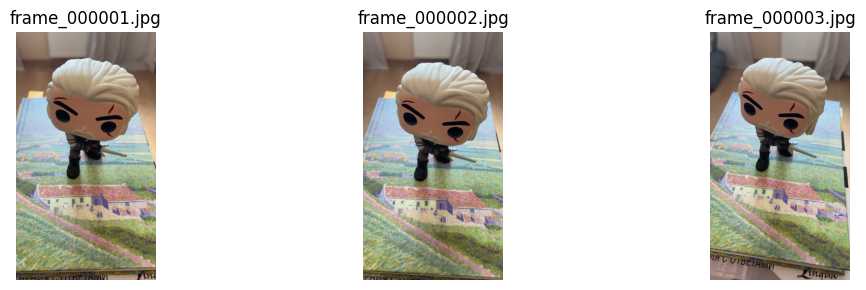

In [4]:
paths = sorted(glob.glob(os.path.join(FRAMES_DIR, '*.jpg')))
if not paths:
    print('Нет jpg в', FRAMES_DIR)
else:
    show = paths[: min(6, len(paths))]
    k = min(3, len(show))
    fig, axs = plt.subplots(1, k, figsize=(4 * k, 3))
    if k == 1:
        axs = [axs]
    for ax, p in zip(axs, show[:k]):
        ax.imshow(cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB))
        ax.set_title(os.path.basename(p))
        ax.axis('off')
    plt.tight_layout()
    plt.show()


## Папка изображений для COLMAP

Если в `frames_filtered` есть файлы, используется она; иначе `frames`.


In [5]:
IMAGES_FOR_COLMAP = (
    FRAMES_FILTERED_DIR
    if glob.glob(os.path.join(FRAMES_FILTERED_DIR, '*.jpg'))
    else FRAMES_DIR
)
print('Папка изображений для COLMAP:', os.path.abspath(IMAGES_FOR_COLMAP))
print('Число изображений:', len(glob.glob(os.path.join(IMAGES_FOR_COLMAP, '*.jpg'))))


Папка изображений для COLMAP: C:\ITMO\designing_neural_network_architectures_2025_02\seminar_04\data\frames
Число изображений: 54


---

# SfM в COLMAP: три команды

1. **`feature_extractor`** — ключевые точки и дескрипторы на каждом изображении.
2. **`exhaustive_matcher`** — сопоставление дескрипторов для каждой пары изображений (для небольших наборов; на больших данных применяют другие матчеры).
3. **`mapper`** — оценка камер и разреженного облака точек.

Перед повторным запуском удалите `database.db` и содержимое `sparse/`.


## SfM  шаг A. Извлечение признаков (`feature_extractor`)

In [6]:
os.makedirs(COLMAP_DIR, exist_ok=True)
if os.path.isfile(DB_PATH):
    os.remove(DB_PATH)
    print('Удалён', DB_PATH)

run(
    f'colmap feature_extractor '
    f'--database_path "{DB_PATH}" '
    f'--image_path "{IMAGES_FOR_COLMAP}" '
    f'--ImageReader.single_camera 1'
)
print('feature_extractor: готово')


>> colmap feature_extractor --database_path "C:\ITMO\designing_neural_network_architectures_2025_02\seminar_04\data\colmap\database.db" --image_path "C:\ITMO\designing_neural_network_architectures_2025_02\seminar_04\data\frames" --ImageReader.single_camera 1
feature_extractor: готово


In [7]:
run(f'colmap exhaustive_matcher --database_path "{DB_PATH}"')
print('exhaustive_matcher: готово')


>> colmap exhaustive_matcher --database_path "C:\ITMO\designing_neural_network_architectures_2025_02\seminar_04\data\colmap\database.db"
exhaustive_matcher: готово


In [8]:
if os.path.isdir(SPARSE_PATH):
    shutil.rmtree(SPARSE_PATH)
os.makedirs(SPARSE_PATH, exist_ok=True)

run(
    f'colmap mapper '
    f'--database_path "{DB_PATH}" '
    f'--image_path "{IMAGES_FOR_COLMAP}" '
    f'--output_path "{SPARSE_PATH}"'
)
print('Модели:', os.path.abspath(SPARSE_PATH))
print('Подкаталоги:', os.listdir(SPARSE_PATH) if os.path.isdir(SPARSE_PATH) else '—')


>> colmap mapper --database_path "C:\ITMO\designing_neural_network_architectures_2025_02\seminar_04\data\colmap\database.db" --image_path "C:\ITMO\designing_neural_network_architectures_2025_02\seminar_04\data\frames" --output_path "C:\ITMO\designing_neural_network_architectures_2025_02\seminar_04\data\colmap\sparse"
Модели: C:\ITMO\designing_neural_network_architectures_2025_02\seminar_04\data\colmap\sparse
Подкаталоги: ['0']


In [9]:
if not os.path.isdir(SPARSE_MODEL_0):
    raise FileNotFoundError(
        f'Нет каталога {SPARSE_MODEL_0}. Проверьте перекрытие видов, текстуру сцены и качество кадров.'
    )

run(f'colmap model_analyzer --path "{SPARSE_MODEL_0}"')


>> colmap model_analyzer --path "C:\ITMO\designing_neural_network_architectures_2025_02\seminar_04\data\colmap\sparse\0"


In [10]:
sparse_ply = os.path.join(SPARSE_MODEL_0, 'sparse_pointcloud.ply')
run(
    f'colmap model_converter '
    f'--input_path "{SPARSE_MODEL_0}" '
    f'--output_path "{sparse_ply}" '
    f'--output_type PLY'
)
print('Сохранено:', os.path.abspath(sparse_ply))


>> colmap model_converter --input_path "C:\ITMO\designing_neural_network_architectures_2025_02\seminar_04\data\colmap\sparse\0" --output_path "C:\ITMO\designing_neural_network_architectures_2025_02\seminar_04\data\colmap\sparse\0\sparse_pointcloud.ply" --output_type PLY
Сохранено: C:\ITMO\designing_neural_network_architectures_2025_02\seminar_04\data\colmap\sparse\0\sparse_pointcloud.ply


C:\ITMO\designing_neural_network_architectures_2025_02\seminar_04\data\colmap\sparse\0\sparse_pointcloud.ply | точек: 26633


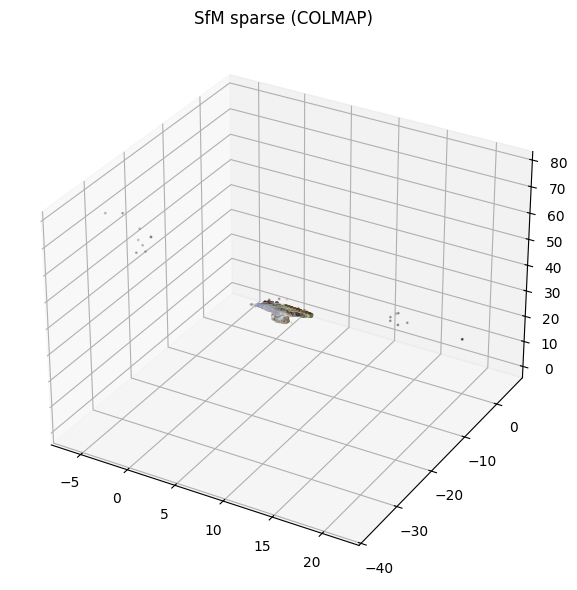

In [11]:
if os.path.isfile(sparse_ply):
    show_ply(sparse_ply, title='SfM sparse (COLMAP)', max_points=70000)
else:
    print('Нет файла:', sparse_ply)


In [12]:
if os.path.isdir(DENSE_WORK):
    shutil.rmtree(DENSE_WORK)
os.makedirs(DENSE_WORK, exist_ok=True)

run(
    f'colmap image_undistorter '
    f'--image_path "{IMAGES_FOR_COLMAP}" '
    f'--input_path "{SPARSE_MODEL_0}" '
    f'--output_path "{DENSE_WORK}" '
    f'--output_type COLMAP'
)
print('Рабочий каталог dense:', os.path.abspath(DENSE_WORK))


>> colmap image_undistorter --image_path "C:\ITMO\designing_neural_network_architectures_2025_02\seminar_04\data\frames" --input_path "C:\ITMO\designing_neural_network_architectures_2025_02\seminar_04\data\colmap\sparse\0" --output_path "C:\ITMO\designing_neural_network_architectures_2025_02\seminar_04\data\dense\workspace" --output_type COLMAP
Рабочий каталог dense: C:\ITMO\designing_neural_network_architectures_2025_02\seminar_04\data\dense\workspace


In [13]:
DEMO_FAST_PATCH_MATCH = False
_pms_opts = '--PatchMatchStereo.geom_consistency true'
if DEMO_FAST_PATCH_MATCH:
    _pms_opts = (
        '--PatchMatchStereo.geom_consistency false '
        '--PatchMatchStereo.max_image_size 1280'
    )

run(
    f'colmap patch_match_stereo '
    f'--workspace_path "{DENSE_WORK}" '
    f'--workspace_format COLMAP '
    f'{_pms_opts}'
)
print('patch_match_stereo: готово')


>> colmap patch_match_stereo --workspace_path "C:\ITMO\designing_neural_network_architectures_2025_02\seminar_04\data\dense\workspace" --workspace_format COLMAP --PatchMatchStereo.geom_consistency true
patch_match_stereo: готово


In [14]:
fused_ply = os.path.join(DENSE_WORK, 'fused.ply')
run(
    f'colmap stereo_fusion '
    f'--workspace_path "{DENSE_WORK}" '
    f'--workspace_format COLMAP '
    f'--input_type geometric '
    f'--output_path "{fused_ply}"'
)
print('Плотное облако:', os.path.abspath(fused_ply))


>> colmap stereo_fusion --workspace_path "C:\ITMO\designing_neural_network_architectures_2025_02\seminar_04\data\dense\workspace" --workspace_format COLMAP --input_type geometric --output_path "C:\ITMO\designing_neural_network_architectures_2025_02\seminar_04\data\dense\workspace\fused.ply"
Плотное облако: C:\ITMO\designing_neural_network_architectures_2025_02\seminar_04\data\dense\workspace\fused.ply


C:\ITMO\designing_neural_network_architectures_2025_02\seminar_04\data\dense\workspace\fused.ply | точек: 1726654


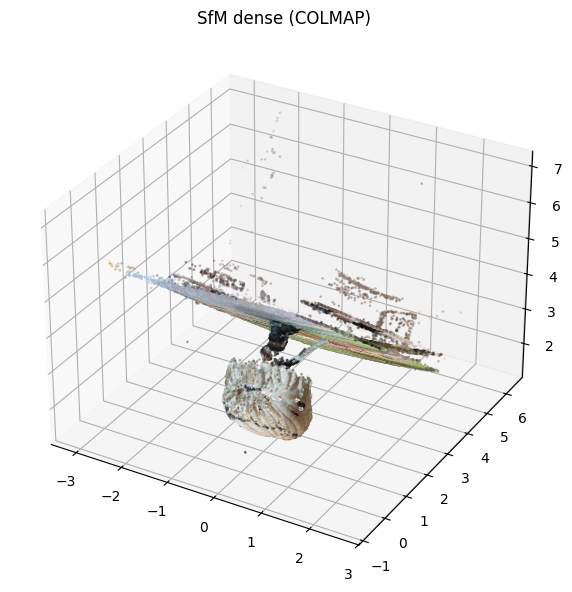

In [15]:
show_ply(fused_ply, title='SfM dense (COLMAP)', max_points=150000)


In [16]:
mesh_out = os.path.join(DENSE_WORK, 'mesh_poisson.ply')
run(
    f'colmap poisson_mesher '
    f'--input_path "{fused_ply}" '
    f'--output_path "{mesh_out}"'
)
print('Меш:', os.path.abspath(mesh_out))


>> colmap poisson_mesher --input_path "C:\ITMO\designing_neural_network_architectures_2025_02\seminar_04\data\dense\workspace\fused.ply" --output_path "C:\ITMO\designing_neural_network_architectures_2025_02\seminar_04\data\dense\workspace\mesh_poisson.ply"
Меш: C:\ITMO\designing_neural_network_architectures_2025_02\seminar_04\data\dense\workspace\mesh_poisson.ply


C:\ITMO\designing_neural_network_architectures_2025_02\seminar_04\data\dense\workspace\mesh_poisson.ply | точек: 4613131


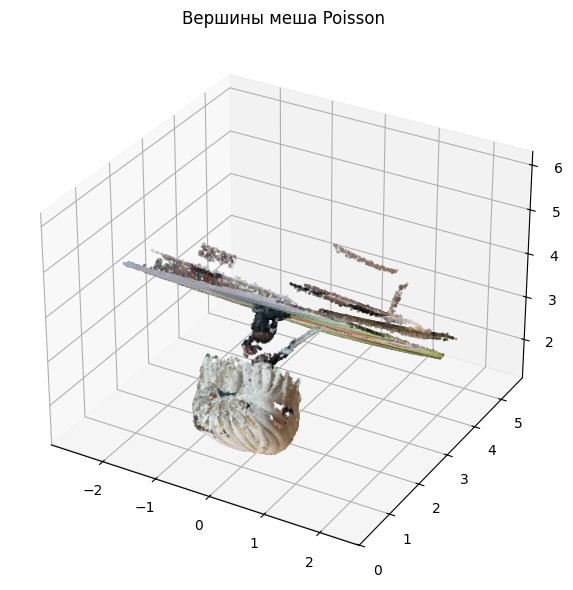

In [17]:

show_ply(mesh_out, title='Вершины меша Poisson', max_points=150000)
